In [1]:
import pandas as pd
import numpy as np
import os
from collections import Counter
def load_wesad_data(directory):
    data = {}
    for participant_id in os.listdir(directory):
        participant_path = os.path.join(directory, participant_id)
        if os.path.isdir(participant_path):
            participant_data = {}
            for file_name in os.listdir(participant_path):
                file_path = os.path.join(participant_path, file_name)
                if file_name.endswith('.pkl'):
                    participant_data[file_name.split('.')[0]] = pd.read_pickle(file_path)
            data[participant_id] = participant_data
    return data

wesad_data = load_wesad_data('C:/Users/rusha/Desktop/Uni_Freiburg_Notes/MDD/WESAD')

In [2]:
def preprocess_data(wesad_data):
    processed_data = {}
    for participant_id, participant_data in wesad_data.items():
        processed_participant_data = {}
        for sensor, data in participant_data.items():
            if isinstance(data, pd.DataFrame):
                data = data.fillna(data.mean())
                data = (data - data.min()) / (data.max() - data.min())
                processed_participant_data[sensor] = data
        processed_data[participant_id] = processed_participant_data
    return processed_data

preprocessed_wesad_data = preprocess_data(wesad_data)

In [3]:
wesad_data['S10']['S10']['signal']['wrist']['BVP'].var()

2139.2899979448866

In [13]:
import numpy as np
import pandas as pd

def calculate_intrapersonal_variances(wesad_data):
    # Initialize a dictionary to hold intrapersonal variances
    intrapersonal_variances = {'BVP': {}, 'EDA': {}, 'TEMP': {}}
    
    # Process each subject
    for subject_id, subject_data in wesad_data.items():
        # Extract wrist data
        wrist_data = wesad_data[subject_id][subject_id]['signal']['wrist']
        
        # Initialize dictionary to hold variances for this subject
        subject_variances = {'BVP': None, 'EDA': None, 'TEMP': None}
        
        # Process BVP
        if 'BVP' in wrist_data:
            bvp_data = wrist_data['BVP']
            # Normalize BVP data
            bvp_data = (bvp_data - np.min(bvp_data)) / (np.max(bvp_data) - np.min(bvp_data))
            # Calculate intrapersonal variance
            subject_variances['BVP'] = np.var(bvp_data, ddof=1)
        
        # Process EDA
        if 'EDA' in wrist_data:
            eda_data = wrist_data['EDA']
            # Normalize EDA data
            eda_data = (eda_data - np.min(eda_data)) / (np.max(eda_data) - np.min(eda_data))
            # Calculate intrapersonal variance
            subject_variances['EDA'] = np.var(eda_data, ddof=1)
        
        # Process TEMP
        if 'TEMP' in wrist_data:
            temp_data = wrist_data['TEMP']
            # Normalize TEMP data
            temp_data = (temp_data - np.min(temp_data)) / (np.max(temp_data) - np.min(temp_data))
            # Calculate intrapersonal variance
            subject_variances['TEMP'] = np.var(temp_data, ddof=1)
        
        # Store the variances for this subject
        for sensor in subject_variances:
            intrapersonal_variances[sensor][subject_id] = subject_variances[sensor]
    
    return intrapersonal_variances

# Compute intrapersonal variances
intrapersonal_variances = calculate_intrapersonal_variances(wesad_data)

# Convert to DataFrames for easier viewing
intra_df = {
    sensor: pd.DataFrame(variances.items(), columns=['Subject', 'Intrapersonal Variance'])
    for sensor, variances in intrapersonal_variances.items()
}

# Display the results
print("Intrapersonal Variances for BVP:")
print(intra_df['BVP'])

print("\nIntrapersonal Variances for EDA:")
print(intra_df['EDA'])

print("\nIntrapersonal Variances for TEMP:")
print(intra_df['TEMP'])


Intrapersonal Variances for BVP:
   Subject  Intrapersonal Variance
0      S10                0.001109
1      S11                0.001243
2      S13                0.001427
3      S14                0.001490
4      S15                0.001012
5      S16                0.000904
6      S17                0.000873
7       S2                0.001661
8       S3                0.000301
9       S4                0.000762
10      S5                0.001246
11      S6                0.000626
12      S7                0.000729
13      S8                0.000762
14      S9                0.000547

Intrapersonal Variances for EDA:
   Subject  Intrapersonal Variance
0      S10                0.055965
1      S11                0.040447
2      S13                0.069296
3      S14                0.000675
4      S15                0.059420
5      S16                0.056028
6      S17                0.016285
7       S2                0.038760
8       S3                0.037466
9       S4             

In [21]:
intra_df

{'BVP':    Subject  Intrapersonal Variance       HRV
 0      S10                0.001109  0.188136
 1      S11                0.001243  0.174852
 2      S13                0.001427  0.143352
 3      S14                0.001490  0.188508
 4      S15                0.001012  0.149576
 5      S16                0.000904  0.195243
 6      S17                0.000873  0.189160
 7       S2                0.001661  0.146972
 8       S3                0.000301  0.228150
 9       S4                0.000762  0.167094
 10      S5                0.001246  0.234520
 11      S6                0.000626  0.137947
 12      S7                0.000729  0.199290
 13      S8                0.000762  0.148930
 14      S9                0.000547  0.182918,
 'EDA':    Subject  Intrapersonal Variance       HRV
 0      S10                0.055965  0.188136
 1      S11                0.040447  0.174852
 2      S13                0.069296  0.143352
 3      S14                0.000675  0.188508
 4      S15        

In [22]:
import pandas as pd
import numpy as np
import os

def load_hrv_data(hrv_directory):
    hrv_data = {}
    for subject_id in os.listdir(hrv_directory):
        file_path = os.path.join(hrv_directory, subject_id, f'{subject_id}_E4_Data', 'HR.csv')
        if os.path.exists(file_path):
            try:
                # Load heart rate data from CSV
                hr_data = pd.read_csv(file_path, header=None)
                
                # Extract sample rate and heart rate data
                sample_rate = float(hr_data.iloc[1, 0])  # Sample rate in Hz
                heart_rate = hr_data.iloc[2:, 0].astype(float)  # Heart rate data
                
                # Convert heart rate to RR intervals (seconds)
                rr_intervals = 60 / heart_rate
                rr_intervals = (rr_intervals - np.min(rr_intervals)) / (np.max(rr_intervals) - np.min(rr_intervals))

                # Calculate HRV (Standard deviation of RR intervals)
                hrv = np.std(rr_intervals, ddof=1)  # Standard deviation of RR intervals
                
                hrv_data[subject_id] = hrv
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
    return hrv_data

def append_hrv_to_intra_df(intra_df, hrv_data):
    # Append HRV to existing DataFrames in intra_df
    updated_intra_df = {}
    
    for sensor, df in intra_df.items():
        # Ensure HRV data matches the subjects in the DataFrame
        if 'Subject' in df.columns:
            df['HRV'] = df['Subject'].map(hrv_data).fillna(np.nan)
            updated_intra_df[sensor] = df
        else:
            print(f"No 'Subject' column found for sensor {sensor}")
    
    return updated_intra_df

# Load HRV data from CSV files
hrv_directory = 'C:/Users/rusha/Desktop/Uni_Freiburg_Notes/MDD/WESAD'
hrv_data = load_hrv_data(hrv_directory)

# Example of intra_df dictionary (assuming it already exists)
# intra_df = {
#     'BVP': pd.DataFrame({'Subject': ['S10', 'S11'], 'Intrapersonal Variance': [0.1, 0.2]}),
#     'EDA': pd.DataFrame({'Subject': ['S10', 'S11'], 'Intrapersonal Variance': [0.3, 0.4]}),
#     'TEMP': pd.DataFrame({'Subject': ['S10', 'S11'], 'Intrapersonal Variance': [0.5, 0.6]})
# }

# Append HRV to intra_df
updated_intra_df = append_hrv_to_intra_df(intra_df, hrv_data)

# Display updated DataFrames
for sensor, df in updated_intra_df.items():
    print(f"Updated DataFrame for {sensor}:")
    print(df)
    print()


Updated DataFrame for BVP:
   Subject  Intrapersonal Variance  HRV
0      S10                0.001109  NaN
1      S11                0.001243  NaN
2      S13                0.001427  NaN
3      S14                0.001490  NaN
4      S15                0.001012  NaN
5      S16                0.000904  NaN
6      S17                0.000873  NaN
7       S2                0.001661  NaN
8       S3                0.000301  NaN
9       S4                0.000762  NaN
10      S5                0.001246  NaN
11      S6                0.000626  NaN
12      S7                0.000729  NaN
13      S8                0.000762  NaN
14      S9                0.000547  NaN

Updated DataFrame for EDA:
   Subject  Intrapersonal Variance  HRV
0      S10                0.055965  NaN
1      S11                0.040447  NaN
2      S13                0.069296  NaN
3      S14                0.000675  NaN
4      S15                0.059420  NaN
5      S16                0.056028  NaN
6      S17               

c:\Users\rusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\rusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\rusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\rusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\rusha\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [23]:
# Example updated DataFrames (assuming these are your existing DataFrames)
bvp_df = pd.DataFrame({
    'Subject': ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'],
    'BVP': [0.001109, 0.001243, 0.001427, 0.001490, 0.001012, 0.000904, 0.000873, 0.001661, 0.000301, 0.000762, 0.001246, 0.000626, 0.000729, 0.000762, 0.000547],
    'HRV': [0.083054, 0.092467, 0.070403, 0.105681, 0.080960, 0.123586, 0.119815, 0.096164, 0.167851, 0.104607, 0.130833, 0.081998, 0.120869, 0.081243, 0.075888]
})

eda_df = pd.DataFrame({
    'Subject': ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'],
    'EDA': [0.055965, 0.040447, 0.069296, 0.000675, 0.059420, 0.056028, 0.016285, 0.038760, 0.037466, 0.052117, 0.045310, 0.071279, 0.055927, 0.040599, 0.029641],
    'HRV_EDA': [0.083054, 0.092467, 0.070403, 0.105681, 0.080960, 0.123586, 0.119815, 0.096164, 0.167851, 0.104607, 0.130833, 0.081998, 0.120869, 0.081243, 0.075888]
})

temp_df = pd.DataFrame({
    'Subject': ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'],
    'TEMP': [0.062056, 0.147513, 0.110282, 0.053648, 0.043823, 0.087088, 0.068084, 0.081574, 0.094117, 0.092221, 0.074219, 0.079873, 0.050710, 0.090382, 0.107554],
    'HRV_TEMP': [0.083054, 0.092467, 0.070403, 0.105681, 0.080960, 0.123586, 0.119815, 0.096164, 0.167851, 0.104607, 0.130833, 0.081998, 0.120869, 0.081243, 0.075888]
})

# Merge DataFrames on 'Subject'
combined_df = pd.merge(bvp_df, eda_df, on='Subject')
combined_df = pd.merge(combined_df, temp_df, on='Subject')

# Display the combined DataFrame

combined_df = combined_df.drop(columns=["HRV_EDA","HRV_TEMP"])
print(combined_df)


   Subject       BVP       HRV       EDA      TEMP
0      S10  0.001109  0.083054  0.055965  0.062056
1      S11  0.001243  0.092467  0.040447  0.147513
2      S13  0.001427  0.070403  0.069296  0.110282
3      S14  0.001490  0.105681  0.000675  0.053648
4      S15  0.001012  0.080960  0.059420  0.043823
5      S16  0.000904  0.123586  0.056028  0.087088
6      S17  0.000873  0.119815  0.016285  0.068084
7       S2  0.001661  0.096164  0.038760  0.081574
8       S3  0.000301  0.167851  0.037466  0.094117
9       S4  0.000762  0.104607  0.052117  0.092221
10      S5  0.001246  0.130833  0.045310  0.074219
11      S6  0.000626  0.081998  0.071279  0.079873
12      S7  0.000729  0.120869  0.055927  0.050710
13      S8  0.000762  0.081243  0.040599  0.090382
14      S9  0.000547  0.075888  0.029641  0.107554


In [24]:
# combined_df["HRV"] = (combined_df["HRV"] - np.min(combined_df["HRV"])) / (np.max(combined_df["HRV"]) - np.min(combined_df["HRV"]))
combined_df

,Subject,BVP,HRV,EDA,TEMP
0,S10,0.001109,0.083054,0.055965,0.062056
1,S11,0.001243,0.092467,0.040447,0.147513
2,S13,0.001427,0.070403,0.069296,0.110282
3,S14,0.001490,0.105681,0.000675,0.053648
4,S15,0.001012,0.080960,0.059420,0.043823
5,S16,0.000904,0.123586,0.056028,0.087088
6,S17,0.000873,0.119815,0.016285,0.068084
7,S2,0.001661,0.096164,0.038760,0.081574
8,S3,0.000301,0.167851,0.037466,0.094117
9,S4,0.000762,0.104607,0.052117,0.092221


In [25]:
# Convert to DataFrame
df = pd.DataFrame(combined_df)

# Metrics to calculate
metrics = ['BVP', 'HRV', 'EDA', 'TEMP']
results = []

for metric in metrics:
    # Get the values for the metric
    values = df[metric]
    
    # Calculate average intrapersonal variance
    avg_intrapersonal_variance = np.mean(values)
    
    # Calculate interpersonal variance (variance of the intrapersonal variances)
    interpersonal_variance = np.var(values)
    
    # Append results
    results.append({
        'Metric': metric,
        'Average Intrapersonal Variance': avg_intrapersonal_variance,
        'Interpersonal Variance': interpersonal_variance
    })

# Create DataFrame
summary_df = pd.DataFrame(results)

print(summary_df)

  Metric  Average Intrapersonal Variance  Interpersonal Variance
0    BVP                        0.000979            1.353584e-07
1    HRV                        0.102361            6.508775e-04
2    EDA                        0.044614            3.373023e-04
3   TEMP                        0.082876            6.651867e-04


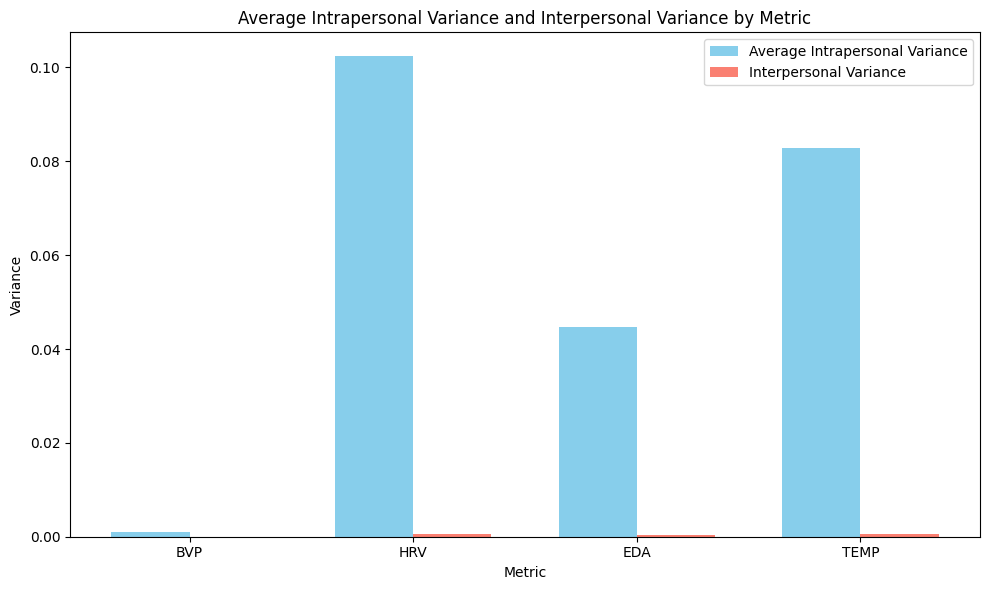

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Define the width of the bars
bar_width = 0.35

# Define positions for the bars
bar_positions1 = np.arange(len(summary_df['Metric']))
bar_positions2 = bar_positions1 + bar_width

# Plot the bars
bars1 = ax.bar(bar_positions1, summary_df['Average Intrapersonal Variance'], bar_width, label='Average Intrapersonal Variance', color='skyblue')
bars2 = ax.bar(bar_positions2, summary_df['Interpersonal Variance'], bar_width, label='Interpersonal Variance', color='salmon')

# Add labels, title, and legend
ax.set_xlabel('Metric')
ax.set_ylabel('Variance')
ax.set_title('Average Intrapersonal Variance and Interpersonal Variance by Metric')
ax.set_xticks(bar_positions1 + bar_width / 2)
ax.set_xticklabels(summary_df['Metric'])
ax.legend()

# Add value labels on top of bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.5f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# add_value_labels(bars1)
# add_value_labels(bars2)

# Show plot
plt.tight_layout()
plt.show()


In [27]:
# # Define your variance calculations for each experiment as shown previously
# # Replace these with actual values calculated similarly as for 'abstract_images'

# # Example data for each subject and experiment:
# # In practice, you should replace these with actual calculations from your data.

# # For 'abstract_images'
# intra_variance_bvp_1_abstract_images = df_bvp_1_abstract_images['values'].var()
# intra_variance_eda_1_abstract_images = df_eda_1_abstract_images['values'].var()
# intra_variance_temp_1_abstract_images = df_temperature_1_abstract_images['values'].var()

# intra_variance_bvp_2_abstract_images = df_bvp_2_abstract_images['values'].var()
# intra_variance_eda_2_abstract_images = df_eda_2_abstract_images['values'].var()
# intra_variance_temp_2_abstract_images = df_temperature_2_abstract_images['values'].var()

# intra_variance_bvp_3_abstract_images = df_bvp_3_abstract_images['values'].var()
# intra_variance_eda_3_abstract_images = df_eda_3_abstract_images['values'].var()
# intra_variance_temp_3_abstract_images = df_temperature_3_abstract_images['values'].var()

hrv_1_abstract_images = hrv_combined["Subject 1"]["abstract_images"]  # Replace with actual HRV calculations
hrv_2_abstract_images = hrv_combined["Subject 2"]["abstract_images"]
hrv_3_abstract_images = hrv_combined["Subject 3"]["abstract_images"]

# # For each experiment, replace the placeholders with similar calculations
# # Example for 'panas'
# intra_variance_bvp_1_panas = df_bvp_1_panas['values'].var()
# intra_variance_eda_1_panas = df_eda_1_panas['values'].var()
# intra_variance_temp_1_panas = df_temperature_1_panas['values'].var()

# intra_variance_bvp_2_panas = df_bvp_2_panas['values'].var()
# intra_variance_eda_2_panas = df_eda_2_panas['values'].var()
# intra_variance_temp_2_panas = df_temperature_2_panas['values'].var()

# intra_variance_bvp_3_panas = df_bvp_3_panas['values'].var()
# intra_variance_eda_3_panas = df_eda_3_panas['values'].var()
# intra_variance_temp_3_panas = df_temperature_3_panas['values'].var()

hrv_1_panas = hrv_combined["Subject 1"]["panas"] 
hrv_2_panas = hrv_combined["Subject 2"]["panas"] 
hrv_3_panas = hrv_combined["Subject 3"]["panas"] 

# # For 'stroop_test'
# intra_variance_bvp_1_stroop_test = df_bvp_1_stroop_test['values'].var()
# intra_variance_eda_1_stroop_test = df_eda_1_stroop_test['values'].var()
# intra_variance_temp_1_stroop_test = df_temperature_1_stroop_test['values'].var()

# intra_variance_bvp_2_stroop_test = df_bvp_2_stroop_test['values'].var()
# intra_variance_eda_2_stroop_test = df_eda_2_stroop_test['values'].var()
# intra_variance_temp_2_stroop_test = df_temperature_2_stroop_test['values'].var()

# intra_variance_bvp_3_stroop_test = df_bvp_3_stroop_test['values'].var()
# intra_variance_eda_3_stroop_test = df_eda_3_stroop_test['values'].var()
# intra_variance_temp_3_stroop_test = df_temperature_3_stroop_test['values'].var()

hrv_1_stroop_test = hrv_combined["Subject 1"]["stroop_test"] 
hrv_2_stroop_test = hrv_combined["Subject 2"]["stroop_test"] 
hrv_3_stroop_test = hrv_combined["Subject 3"]["stroop_test"] 

# # For 'storytelling'
# intra_variance_bvp_1_storytelling = df_bvp_1_storytelling['values'].var()
# intra_variance_eda_1_storytelling = df_eda_1_storytelling['values'].var()
# intra_variance_temp_1_storytelling = df_temperature_1_storytelling['values'].var()

# intra_variance_bvp_2_storytelling = df_bvp_2_storytelling['values'].var()
# intra_variance_eda_2_storytelling = df_eda_2_storytelling['values'].var()
# intra_variance_temp_2_storytelling = df_temperature_2_storytelling['values'].var()

# intra_variance_bvp_3_storytelling = df_bvp_3_storytelling['values'].var()
# intra_variance_eda_3_storytelling = df_eda_3_storytelling['values'].var()
# intra_variance_temp_3_storytelling = df_temperature_3_storytelling['values'].var()

hrv_1_storytelling = hrv_combined["Subject 1"]["storytelling"] 
hrv_2_storytelling = hrv_combined["Subject 2"]["storytelling"] 
hrv_3_storytelling = hrv_combined["Subject 3"]["storytelling"] 

# # For 'videos'
# intra_variance_bvp_1_videos = df_bvp_1_videos['values'].var()
# intra_variance_eda_1_videos = df_eda_1_videos['values'].var()
# intra_variance_temp_1_videos = df_temperature_1_videos['values'].var()

# intra_variance_bvp_2_videos = df_bvp_2_videos['values'].var()
# intra_variance_eda_2_videos = df_eda_2_videos['values'].var()
# intra_variance_temp_2_videos = df_temperature_2_videos['values'].var()

# intra_variance_bvp_3_videos = df_bvp_3_videos['values'].var()
# intra_variance_eda_3_videos = df_eda_3_videos['values'].var()
# intra_variance_temp_3_videos = df_temperature_3_videos['values'].var()

hrv_1_videos = hrv_combined["Subject 1"]["videos"] 
hrv_2_videos = hrv_combined["Subject 2"]["videos"] 
hrv_3_videos = hrv_combined["Subject 3"]["videos"] 

# # For 'standard_images'
# intra_variance_bvp_1_standard_images = df_bvp_1_standard_images['values'].var()
# intra_variance_eda_1_standard_images = df_eda_1_standard_images['values'].var()
# intra_variance_temp_1_standard_images = df_temperature_1_standard_images['values'].var()

# intra_variance_bvp_2_standard_images = df_bvp_2_standard_images['values'].var()
# intra_variance_eda_2_standard_images = df_eda_2_standard_images['values'].var()
# intra_variance_temp_2_standard_images = df_temperature_2_standard_images['values'].var()

# intra_variance_bvp_3_standard_images = df_bvp_3_standard_images['values'].var()
# intra_variance_eda_3_standard_images = df_eda_3_standard_images['values'].var()
# intra_variance_temp_3_standard_images = df_temperature_3_standard_images['values'].var()

hrv_1_standard_images = hrv_combined["Subject 1"]["standard_images"] 
hrv_2_standard_images = hrv_combined["Subject 2"]["standard_images"] 
hrv_3_standard_images = hrv_combined["Subject 3"]["standard_images"] 

# # Combine intrapersonal variances into a DataFrame for each experiment
# intrapersonal_variances_dict = {
#     'abstract_images': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_abstract_images, 'Subject 2': hrv_2_abstract_images, 'Subject 3': hrv_3_abstract_images},
#         'BVP': {'Subject 1': intra_variance_bvp_1_abstract_images, 'Subject 2': intra_variance_bvp_2_abstract_images, 'Subject 3': intra_variance_bvp_3_abstract_images},
#         'EDA': {'Subject 1': intra_variance_eda_1_abstract_images, 'Subject 2': intra_variance_eda_2_abstract_images, 'Subject 3': intra_variance_eda_3_abstract_images},
#         'Temperature': {'Subject 1': intra_variance_temp_1_abstract_images, 'Subject 2': intra_variance_temp_2_abstract_images, 'Subject 3': intra_variance_temp_3_abstract_images}
#     }),
#     'panas': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_panas, 'Subject 2': hrv_2_panas, 'Subject 3': hrv_3_panas},
#         'BVP': {'Subject 1': intra_variance_bvp_1_panas, 'Subject 2': intra_variance_bvp_2_panas, 'Subject 3': intra_variance_bvp_3_panas},
#         'EDA': {'Subject 1': intra_variance_eda_1_panas, 'Subject 2': intra_variance_eda_2_panas, 'Subject 3': intra_variance_eda_3_panas},
#         'Temperature': {'Subject 1': intra_variance_temp_1_panas, 'Subject 2': intra_variance_temp_2_panas, 'Subject 3': intra_variance_temp_3_panas}
#     }),
#     'stroop_test': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_stroop_test, 'Subject 2': hrv_2_stroop_test, 'Subject 3': hrv_3_stroop_test},
#         'BVP': {'Subject 1': intra_variance_bvp_1_stroop_test, 'Subject 2': intra_variance_bvp_2_stroop_test, 'Subject 3': intra_variance_bvp_3_stroop_test},
#         'EDA': {'Subject 1': intra_variance_eda_1_stroop_test, 'Subject 2': intra_variance_eda_2_stroop_test, 'Subject 3': intra_variance_eda_3_stroop_test},
#         'Temperature': {'Subject 1': intra_variance_temp_1_stroop_test, 'Subject 2': intra_variance_temp_2_stroop_test, 'Subject 3': intra_variance_temp_3_stroop_test}
#     }),
#     'storytelling': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_storytelling, 'Subject 2': hrv_2_storytelling, 'Subject 3': hrv_3_storytelling},
#         'BVP': {'Subject 1': intra_variance_bvp_1_storytelling, 'Subject 2': intra_variance_bvp_2_storytelling, 'Subject 3': intra_variance_bvp_3_storytelling},
#         'EDA': {'Subject 1': intra_variance_eda_1_storytelling, 'Subject 2': intra_variance_eda_2_storytelling, 'Subject 3': intra_variance_eda_3_storytelling},
#         'Temperature': {'Subject 1': intra_variance_temp_1_storytelling, 'Subject 2': intra_variance_temp_2_storytelling, 'Subject 3': intra_variance_temp_3_storytelling}
#     }),
#     'videos': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_videos, 'Subject 2': hrv_2_videos, 'Subject 3': hrv_3_videos},
#         'BVP': {'Subject 1': intra_variance_bvp_1_videos, 'Subject 2': intra_variance_bvp_2_videos, 'Subject 3': intra_variance_bvp_3_videos},
#         'EDA': {'Subject 1': intra_variance_eda_1_videos, 'Subject 2': intra_variance_eda_2_videos, 'Subject 3': intra_variance_eda_3_videos},
#         'Temperature': {'Subject 1': intra_variance_temp_1_videos, 'Subject 2': intra_variance_temp_2_videos, 'Subject 3': intra_variance_temp_3_videos}
#     }),
#     'standard_images': pd.DataFrame({
#         'HRV': {'Subject 1': hrv_1_standard_images, 'Subject 2': hrv_2_standard_images, 'Subject 3': hrv_3_standard_images},
#         'BVP': {'Subject 1': intra_variance_bvp_1_standard_images, 'Subject 2': intra_variance_bvp_2_standard_images, 'Subject 3': intra_variance_bvp_3_standard_images},
#         'EDA': {'Subject 1': intra_variance_eda_1_standard_images, 'Subject 2': intra_variance_eda_2_standard_images, 'Subject 3': intra_variance_eda_3_standard_images},
#         'Temperature': {'Subject 1': intra_variance_temp_1_standard_images, 'Subject 2': intra_variance_temp_2_standard_images, 'Subject 3': intra_variance_temp_3_standard_images}
#     })
# }

NameError: name 'hrv_combined' is not defined

In [ ]:
import pandas as pd
import numpy as np

# Define the function to compute variances
def compute_wesad_variances(wesad_data):
    # Initialize dictionaries for storing variances
    intrapersonal_variances = {}
    interpersonal_variances = {'HRV': [], 'EDA': [], 'BVP': [], 'Temperature': []}
    
    # Process each subject
    for subject, data in wesad_data.items():
        # Extract data
        chest_data = data['signal']['chest']
        wrist_data = data['signal']['wrist']
        
        # Dictionary to store intrapersonal variances for this subject
        subject_intra_variances = {}
        
        for sensor in ['HRV', 'EDA', 'BVP', 'Temperature']:
            if sensor in chest_data:
                sensor_data = chest_data[sensor]
            elif sensor in wrist_data:
                sensor_data = wrist_data[sensor]
            else:
                continue
            
            # Normalize the data
            sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data))
            
            # Calculate intrapersonal variance (variance within this subject)
            intra_var = np.var(sensor_data, ddof=1)
            subject_intra_variances[sensor] = intra_var
            
            # Store for interpersonal variance calculation
            interpersonal_variances[sensor].append(np.mean(sensor_data))
        
        intrapersonal_variances[subject] = subject_intra_variances
    
    # Calculate overall interpersonal variance (between subjects)
    overall_interpersonal_variances = {}
    for sensor in ['HRV', 'EDA', 'BVP', 'Temperature']:
        if len(interpersonal_variances[sensor]) > 1:
            overall_interpersonal_variances[sensor] = np.var(interpersonal_variances[sensor], ddof=1)
    
    return intrapersonal_variances, overall_interpersonal_variances

# Compute the variances
intrapersonal_variances, overall_interpersonal_variances = compute_wesad_variances(wesad_data)

# Convert to DataFrames for easier viewing
intra_df = pd.DataFrame(intrapersonal_variances).T
inter_df = pd.DataFrame.from_dict(overall_interpersonal_variances, orient='index', columns=['Interpersonal Variance'])

# Display the results
print("Intrapersonal Variances:")
print(intra_df)

print("\nInterpersonal Variances:")
print(inter_df)


KeyError: 'signal'

In [ ]:
# Assuming subject data is loaded similarly to subject_s10_data, and `subject_s10_data` is one example
# Let's assume you have a similar structure for all subjects in a directory, we'll combine them
all_subjects_data = {}

# Load and structure the data for all subjects
for subject_id in ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10']:  # Include all subject IDs
    # The following function load_subject_data is hypothetical and should be replaced with the actual loading code
    subject_data = wesad_data(subject_id)  # Replace with actual loading code or variable
    all_subjects_data[subject_id] = subject_data

# Now `all_subjects_data` contains data for all subjects in the same format as `subject_s10_data`


TypeError: 'dict' object is not callable

In [ ]:
subject_s10_data

{'S10': {'signal': {'chest': {'ACC': array([[ 1.12779999,  0.15199995,  0.34159994],
           [ 1.09319997,  0.18879998,  0.29219997],
           [ 1.03539991,  0.20940006,  0.18579996],
           ...,
           [ 0.89419997,  0.03380001, -0.21460003],
           [ 0.89499998,  0.03419995, -0.21820003],
           [ 0.89639997,  0.03260005, -0.22140002]]),
    'ECG': array([[-1.33369446],
           [-1.32774353],
           [-1.32206726],
           ...,
           [ 0.53050232],
           [ 0.53375244],
           [ 0.54057312]]),
    'EMG': array([[-0.01368713],
           [-0.02192688],
           [-0.00901794],
           ...,
           [ 0.00654602],
           [-0.00141907],
           [-0.00814819]]),
    'EDA': array([[0.71601868],
           [0.7144928 ],
           [0.71563721],
           ...,
           [1.70440674],
           [1.74827576],
           [1.72462463]]),
    'Temp': array([[33.69586 ],
           [33.741333],
           [33.71707 ],
           ...,
    

In [ ]:
import pandas as pd
import numpy as np

# Assuming 'preprocessed_wesad_data' is the preprocessed data dictionary
def compute_variances(preprocessed_wesad_data):
    intrapersonal_variances = {}
    interpersonal_variances = {'HRV': [], 'EDA': [], 'BVP': [], 'Temperature': []}
    
    for participant_id, participant_data in preprocessed_wesad_data.items():
        subject_intra_variances = {}
        
        for sensor in ['HRV', 'EDA', 'BVP', 'Temperature']:
            if sensor in participant_data:
                # Calculate intrapersonal variance (over time for each subject)
                intra_var = participant_data[sensor].var(axis=0)
                subject_intra_variances[sensor] = intra_var.mean()  # Mean variance across all channels (if applicable)
                
                # Store for interpersonal variance calculation
                interpersonal_variances[sensor].append(participant_data[sensor].mean(axis=0).mean())
        
        intrapersonal_variances[participant_id] = subject_intra_variances
    
    # Calculate overall interpersonal variance (between subjects)
    overall_interpersonal_variances = {}
    for sensor in ['HRV', 'EDA', 'BVP', 'Temperature']:
        overall_interpersonal_variances[sensor] = np.var(interpersonal_variances[sensor])
    
    return intrapersonal_variances, overall_interpersonal_variances

# Compute the variances
intrapersonal_variances, overall_interpersonal_variances = compute_variances(preprocessed_wesad_data)

# Convert to DataFrame for easier viewing and analysis
intra_df = pd.DataFrame(intrapersonal_variances).T
inter_df = pd.DataFrame.from_dict(overall_interpersonal_variances, orient='index', columns=['Interpersonal Variance'])

# Display the results
print("Intrapersonal Variances:")
print(intra_df)

print("\nInterpersonal Variances:")
print(inter_df)


In [ ]:
labels = wesad_data["S10"]["S10"]["label"]
print(Counter(labels).keys()) # equals to list(set(words))
print(Counter(labels).values())

dict_keys([0, 1, 5, 3, 7, 4, 2, 6])
dict_values([1589000, 826000, 35700, 260400, 39900, 557200, 507500, 31500])


In [ ]:
'''IGNORE FOR NOW'''


# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# # Train the Random Forest classifier
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

# # Predict on the test set
# y_pred = model.predict(X_test)

# # Evaluate the model
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Accuracy: {accuracy}')
# print(classification_report(y_test, y_pred))

In [ ]:
# subject 's10'
subject_s10_data = wesad_data['S10']

print("Structure of data for subject S10:")
s = subject_s10_data['S10']['signal']['chest']['Temp']
print(s.shape)


Structure of data for subject S10:
(3847200, 1)


In [ ]:
time_original = np.linspace(0, len(s) / 64, len(s))
print(len(time_original))
time_target = np.linspace(0, len(s) / 64, 3847200)
print(len(time_target))
time_target = time_target.reshape(-1, 1)
time_original = time_original.reshape(-1, 1)

351744
3847200


In [ ]:
print(time_target.shape)
print(time_original.shape)
print(s.shape)

(3847200, 1)
(351744, 1)
(351744, 1)


In [ ]:
y_new = np.interp(time_target, time_original, s)

ValueError: object too deep for desired array

In [ ]:
subject_s10_data = wesad_data['S10']
s10_data_details = subject_s10_data['S10']
labels_s10 = s10_data_details['label']
print("labels for subject S10:")
print(labels_s10)

labels for subject S10:
[0 0 0 ... 0 0 0]


In [ ]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def extract_and_process_data(subject_id):
    subject_data = wesad_data[subject_id]
    subject_details = subject_data[subject_id]
    chest_data = subject_details['signal']['chest']
    labels = subject_details['label']
    
    # flatten and reshape each signal
    ecg = chest_data['ECG'].flatten().reshape(-1, 1)
    emg = chest_data['EMG'].flatten().reshape(-1, 1)
    eda = chest_data['EDA'].flatten().reshape(-1, 1)
    temp = chest_data['Temp'].flatten().reshape(-1, 1)
    resp = chest_data['Resp'].flatten().reshape(-1, 1)
    
    # print the shapes of all features
    print(f"ECG shape: {ecg.shape}")
    print(f"EMG shape: {emg.shape}")
    print(f"EDA shape: {eda.shape}")
    print(f"TEMP shape: {temp.shape}")
    print(f"RESP shape: {resp.shape}")
    
    # combine the features into a single array
    features = np.hstack((
        ecg,
        emg,
        eda,
        temp,
        resp
    ))

    return features, labels

# extract and process data from subjects S10 and S11
features_s10, labels_s10 = extract_and_process_data('S10')
features_s11, labels_s11 = extract_and_process_data('S11')

# combine features and labels from both subjects
combined_features = np.vstack((features_s10, features_s11))
combined_labels = np.hstack((labels_s10, labels_s11))

l = pd.DataFrame(np.hstack((combined_features, combined_labels.reshape(-1, 1))))

ECG shape: (3847200, 1)
EMG shape: (3847200, 1)
EDA shape: (3847200, 1)
TEMP shape: (3847200, 1)
RESP shape: (3847200, 1)
ECG shape: (3663100, 1)
EMG shape: (3663100, 1)
EDA shape: (3663100, 1)
TEMP shape: (3663100, 1)
RESP shape: (3663100, 1)


In [ ]:
l = l[l[5] != 5]
l = l[l[5] != 6]
l = l[l[5] != 7]

In [ ]:
combined_features = l.loc[:,:4]
combined_labels = l.loc[:, 5]
print(combined_features)
print(combined_labels)


                0         1         2          3         4
0       -1.333694 -0.013687  0.716019  33.695862  0.213623
1       -1.327744 -0.021927  0.714493  33.741333  0.192261
2       -1.322067 -0.009018  0.715637  33.717072  0.205994
3       -1.316345 -0.002380  0.714874  33.741333  0.193787
4       -1.310257  0.001053  0.715256  33.747406  0.172424
...           ...       ...       ...        ...       ...
7510295 -0.027145 -0.045914  6.463242  35.029724 -0.650024
7510296 -0.032822 -0.047928  6.377792  34.989563 -0.669861
7510297 -0.026779 -0.045502  6.378174  35.014282 -0.639343
7510298 -0.006821 -0.041977  6.377029  35.018921 -0.648499
7510299  0.016434 -0.020828  6.380081  35.023529 -0.682068

[7296801 rows x 5 columns]
0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
7510295    0.0
7510296    0.0
7510297    0.0
7510298    0.0
7510299    0.0
Name: 5, Length: 7296801, dtype: float64


In [ ]:
# check initial label distribution
initial_label_distribution = Counter(combined_labels)
print("Initial label distribution:", initial_label_distribution)

X_train, X_test, y_train, y_test = train_test_split(combined_features, combined_labels, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=10, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

# check the label distribution in  training set
label_distribution_train = Counter(y_train)
print("Label distribution in the training set:", label_distribution_train)

# check the label distribution in test set
label_distribution_test = Counter(y_test)
print("Label distribution in the test set:", label_distribution_test)


Initial label distribution: Counter({0.0: 3032400, 1.0: 1652000, 4.0: 1110901, 2.0: 983500, 3.0: 518000})
Accuracy: 0.9337141392705437
Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.93    607025
         1.0       0.99      0.99      0.99    330537
         2.0       0.96      0.94      0.95    196988
         3.0       0.89      0.87      0.88    103660
         4.0       0.89      0.87      0.88    221151

    accuracy                           0.93   1459361
   macro avg       0.93      0.92      0.93   1459361
weighted avg       0.93      0.93      0.93   1459361

Label distribution in the training set: Counter({0.0: 2425375, 1.0: 1321463, 4.0: 889750, 2.0: 786512, 3.0: 414340})
Label distribution in the test set: Counter({0.0: 607025, 1.0: 330537, 4.0: 221151, 2.0: 196988, 3.0: 103660})


In [ ]:
len(s10_data_details["signal"]["wrist"]["TEMP"])

21984

In [ ]:
features_s10 = s10_data_details['signal']['wrist']['ACC']
labels_s10 = s10_data_details['label']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_s10_normalized = scaler.fit_transform(features_s10)

In [ ]:
print("Shape of features_s10:", features_s10.shape)
print("Shape of labels_s10:", labels_s10.shape)

Shape of features_s10: (175872, 3)
Shape of labels_s10: (3847200,)


In [ ]:
print(Counter(labels_s10).keys()) # equals to list(set(words))
print(Counter(labels_s10).values())

dict_keys([0, 1, 5, 3, 7, 4, 2, 6])
dict_values([1589000, 826000, 35700, 260400, 39900, 557200, 507500, 31500])


In [ ]:
# ensure number of rows in features_s10 matches no. of labels
n_samples = min(features_s10.shape[0], len(labels_s10))

# trim features and labels to have same no. of samples
features_s10_trimmed = features_s10[:n_samples]
labels_s10_trimmed = labels_s10[:n_samples]

X_train, X_test, y_train, y_test = train_test_split(features_s10_trimmed, labels_s10_trimmed, test_size=0.2, random_state=42)

In [ ]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
print(Counter(y_train).keys()) # equals to list(set(words))
print(Counter(y_train).values())

dict_keys([0, 1])
dict_values([52090, 88607])


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"accuracy: {accuracy:.2f}")
print("classification report:")
print(report)

accuracy: 0.94
classification report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     12910
           1       0.95      0.95      0.95     22265

    accuracy                           0.94     35175
   macro avg       0.94      0.94      0.94     35175
weighted avg       0.94      0.94      0.94     35175



In [ ]:
import numpy as np
import pandas as pd

# extract the wrist data and labels for subject S10
subject_s10_data = wesad_data['S11']
s10_data_details = subject_s10_data['S11']

wrist_data = s10_data_details['signal']['wrist']
labels_s10 = s10_data_details['label']

# determine the minimum length
min_length = min(
    wrist_data['ACC'].shape[0],
    wrist_data['BVP'].shape[0],
    wrist_data['EDA'].shape[0],
    wrist_data['TEMP'].shape[0]
)

# trim all arrays to minimum length
acc_trimmed = wrist_data['ACC'][:min_length]
bvp_trimmed = wrist_data['BVP'][:min_length]
eda_trimmed = wrist_data['EDA'][:min_length]
temp_trimmed = wrist_data['TEMP'][:min_length]

# combine wrist data components into a single DataFrame
features_s10 = np.hstack((acc_trimmed, bvp_trimmed, eda_trimmed, temp_trimmed))

# ensure that the number of rows in features_s10 matches the number of labels
n_samples = min(features_s10.shape[0], len(labels_s10))

# trim features and labels to have the same number of samples
features_s10_trimmed = features_s10[:n_samples]
labels_s10_trimmed = labels_s10[:n_samples]


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_s10_normalized = scaler.fit_transform(features_s10_trimmed)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features_s10_normalized, labels_s10_trimmed, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


clf = RandomForestClassifier(n_estimators=100, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)


Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4187

    accuracy                           1.00      4187
   macro avg       1.00      1.00      1.00      4187
weighted avg       1.00      1.00      1.00      4187



In [ ]:
import numpy as np
from collections import Counter

# Check class distribution in the dataset
label_counts = Counter(labels_s10_trimmed)
print("Label distribution:", label_counts)

Label distribution: Counter({0: 20932})


In [ ]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def extract_and_process_data(subject_id):
    subject_data = wesad_data[subject_id]
    subject_details = subject_data[subject_id]
    wrist_data = subject_details['signal']['wrist']
    labels = subject_details['label']

    # ensuring labels are within a valid range
    valid_labels = np.isin(labels, [0, 1, 2, 3, 4])
    labels = labels[valid_labels]
    
    # downsample the features to match the labels' length
    def downsample(signal, target_length):
        return signal[:target_length] 

    num_samples = len(labels)

    features = np.hstack((
        downsample(wrist_data['ACC'], num_samples),
        downsample(wrist_data['BVP'], num_samples),
        downsample(wrist_data['EDA'], num_samples),
        downsample(wrist_data['TEMP'], num_samples)
    ))

    return features, labels

features_s10, labels_s10 = extract_and_process_data('S10')
features_s11, labels_s11 = extract_and_process_data('S11')

combined_features = np.vstack((features_s10, features_s11))
combined_labels = np.hstack((labels_s10, labels_s11))

initial_label_distribution = Counter(combined_labels)
print("Initial label distribution:", initial_label_distribution)

valid_labels = np.isin(combined_labels, [0, 1, 2, 3, 4])
balanced_features = combined_features[valid_labels]
balanced_labels = combined_labels[valid_labels]


min_samples_per_class = min(Counter(balanced_labels).values())

balanced_features_list = []
balanced_labels_list = []

for label in np.unique(balanced_labels):
    label_indices = np.where(balanced_labels == label)[0]
    sampled_indices = np.random.choice(label_indices, min_samples_per_class, replace=False)
    balanced_features_list.append(balanced_features[sampled_indices])
    balanced_labels_list.append(balanced_labels[sampled_indices])

# Convert the balanced features and labels to numpy arrays
balanced_features = np.vstack(balanced_features_list)
balanced_labels = np.hstack(balanced_labels_list)


balanced_label_distribution = Counter(balanced_labels)
print("Balanced label distribution:", balanced_label_distribution)

X_train, X_test, y_train, y_test = train_test_split(balanced_features, balanced_labels, test_size=0.2, random_state=42, stratify=balanced_labels)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

label_distribution_train = Counter(y_train)
print("Label distribution in the training set:", label_distribution_train)

label_distribution_test = Counter(y_test)
print("Label distribution in the test set:", label_distribution_test)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 175872 and the array at index 1 has size 351744

In [ ]:

# Extract and combine data from subjects S10 and S11
features_s10, labels_s10 = extract_wrist_data_labels('S10')
features_s11, labels_s11 = extract_wrist_data_labels('S11')

combined_features = np.vstack((features_s10, features_s11))
combined_labels = np.hstack((labels_s10, labels_s11))


initial_label_distribution = Counter(combined_labels)
print("Initial label distribution:", initial_label_distribution)




Initial label distribution: Counter({0: 42916})
